# Exploratory Data Analysis: AITEX Fabric Defect Dataset

This notebook provides comprehensive analysis of the AITEX Fabric Image Database, including:
- Dataset overview and statistics
- Defect type distribution and characteristics
- Visual inspection of defects (original, mask, cropped)
- Spatial and size analysis
- Fabric-defect correlations

## 1. Setup & Imports

In [1]:
import sys
import warnings
# warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Import custom modules
from data_loader import (
    load_dataset_info,
    get_sample_images,
    DEFECT_CODES
)
from eda import (
    add_mask_statistics_to_dataframe,
    compute_defect_statistics,
    compute_fabric_statistics,
    compute_fabric_defect_matrix,
    compute_spatial_statistics,
    get_summary_table,
    analyze_defect_orientation,
    plot_image_triplet,
    plot_multiple_triplets,
    plot_defect_distribution,
    plot_fabric_distribution,
    plot_defect_size_distribution,
    plot_defect_size_by_type,
    plot_fabric_defect_heatmap,
    plot_spatial_heatmap,
    plot_interactive_defect_explorer,
    plot_defect_percentage_distribution,
    plot_orientation_analysis
)

# Display settings
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All modules imported successfully!")

✓ All modules imported successfully!


## 2. Load Dataset

In [2]:
# Load dataset information
print("Loading dataset information...")
df = load_dataset_info()

print(f"✓ Loaded {len(df)} images")
print(f"  - Defect images: {df['has_defect'].sum()}")
print(f"  - Non-defect images: {(~df['has_defect']).sum()}")

# Display first few rows
df.head(10)

Loading dataset information...
✓ Loaded 247 images
  - Defect images: 106
  - Non-defect images: 141


,image_id,defect_code,fabric_code,defect_name,has_defect,image_path,mask_path
0,1,2,0,Broken end,True,/home/user/PycharmProjects/CVpipeline/data/AIT...,/home/user/PycharmProjects/CVpipeline/data/AIT...
1,1,0,4,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
2,1,0,6,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
3,1,0,1,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
4,1,0,3,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
5,1,0,2,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
6,1,0,5,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
7,1,0,0,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
8,2,0,6,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN
9,2,0,5,No Defect,False,/home/user/PycharmProjects/CVpipeline/data/AIT...,NaN


## 3. Compute Mask Statistics

In [3]:
# Compute detailed statistics from masks
print("Computing mask statistics (this may take a minute)...")
df = add_mask_statistics_to_dataframe(df)

print("✓ Statistics computed!")

# Display defect images with statistics
df[df['has_defect'] == True][[
    'image_id', 'defect_name', 'fabric_code', 
    'defect_area', 'defect_percentage', 'aspect_ratio'
]].head(10)

Computing mask statistics (this may take a minute)...
✓ Statistics computed!


,image_id,defect_name,fabric_code,defect_area,defect_percentage,aspect_ratio
0,1,Broken end,0,12054.00,0.13,0.20
11,2,Broken end,0,14271.00,0.12,0.31
21,3,Broken end,0,2233.00,0.04,0.38
31,4,Broken end,1,7530.00,0.20,0.12
34,5,Broken end,1,6100.00,0.24,0.10
45,6,Broken end,1,676.00,0.03,0.25
69,10,Broken yarn,2,16384.00,0.22,0.25
83,11,Broken yarn,2,16077.00,0.22,0.30
85,12,Broken yarn,2,4216.00,0.14,0.07
95,13,Broken yarn,2,2816.00,0.11,0.04


## 4. Dataset Overview

In [4]:
# Display summary table
summary = get_summary_table(df)
print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
display(summary)

# Display defect code mapping
print("\n" + "="*50)
print("DEFECT TYPES")
print("="*50)
defect_mapping = pd.DataFrame([
    {'Code': code, 'Defect Name': name}
    for code, name in DEFECT_CODES.items() if code != 0
])
display(defect_mapping)


DATASET SUMMARY


,Metric,Value
0,Total Images,247
1,Defect Images,106
2,Non-Defect Images,141
3,Defect Types,12
4,Fabric Types,8
5,Image Resolution,4096 × 256
6,Avg Defect Area (pixels),19220
7,Avg Defect Coverage (%),0.453



DEFECT TYPES


,Code,Defect Name
0,2,Broken end
1,6,Broken yarn
2,10,Broken pick
3,16,Weft curling
4,19,Fuzzyball
5,22,Cut selvage
6,23,Crease
7,25,Warp ball
8,27,Knots
9,29,Contamination


## 5. Defect Statistics

### 5.1 Defect Type Distribution

In [5]:
# Compute defect statistics
defect_stats = compute_defect_statistics(df)
display(defect_stats)

,defect_code,defect_name,count,defect_area_mean,defect_area_std,defect_area_min,defect_area_max,defect_area_median,defect_percentage_mean,defect_percentage_std,defect_percentage_min,defect_percentage_max,aspect_ratio_mean,aspect_ratio_median,bbox_width_mean,bbox_width_median,bbox_height_mean,bbox_height_median,percentage
4,19,Fuzzyball,39,41.97,27.83,9.00,130.00,32.50,0.00,0.00,0.00,0.01,1.14,1.00,6.50,6.00,5.97,6.00,36.79
10,30,Nep,14,554.38,751.06,28.00,2220.00,160.00,0.01,0.01,0.00,0.05,0.73,0.77,12.00,10.00,40.31,13.00,13.21
2,10,Broken pick,10,110925.90,116571.54,0.00,307122.00,54971.50,2.07,4.16,0.00,13.66,21.60,19.41,1443.80,1182.50,56.90,51.50,9.43
0,2,Broken end,9,5252.67,5111.83,603.00,14271.00,2751.00,0.10,0.08,0.02,0.24,0.19,0.16,27.67,25.00,161.89,176.00,8.49
5,22,Cut selvage,9,721.78,528.21,108.00,1596.00,475.00,0.03,0.01,0.01,0.05,6.99,6.70,69.11,63.00,11.67,10.00,8.49
1,6,Broken yarn,8,16656.25,18651.42,1958.00,53965.00,10146.50,0.19,0.10,0.08,0.39,0.31,0.16,71.75,40.50,236.50,249.00,7.55
7,25,Warp ball,6,20.60,7.13,12.00,30.00,20.00,0.00,0.00,0.00,0.00,1.04,1.00,4.60,5.00,4.40,4.00,5.66
6,23,Crease,5,9505.60,6840.15,3430.00,17085.00,5588.00,0.09,0.04,0.06,0.14,0.15,0.09,37.60,22.00,252.20,254.00,4.72
3,16,Weft curling,3,15063.67,15443.78,3135.00,32508.00,9548.00,0.08,0.04,0.04,0.12,4.83,1.95,208.67,252.00,84.00,95.00,2.83
8,27,Knots,1,528.00,NaN,528.00,528.00,528.00,0.03,NaN,0.03,0.03,0.23,0.23,11.00,11.00,48.00,48.00,0.94


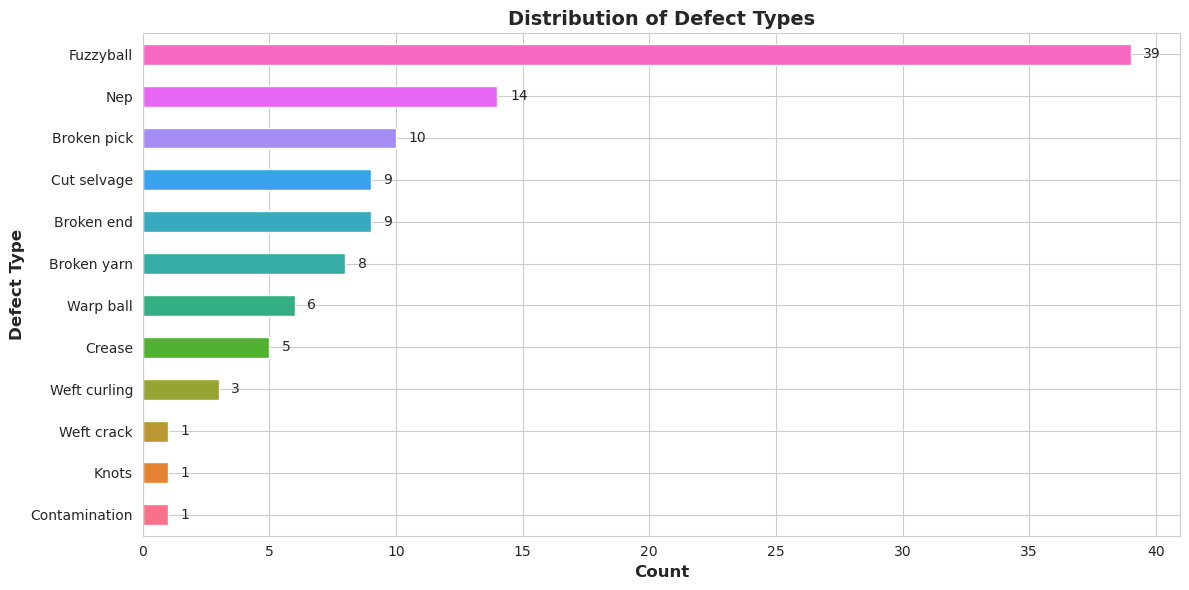

In [6]:
# Visualize defect distribution
fig = plot_defect_distribution(df)
plt.show()

### 5.2 Fabric Type Distribution

In [7]:
# Compute fabric statistics
fabric_stats = compute_fabric_statistics(df)
display(fabric_stats)

,fabric_code,total_images,defect_images,no_defect_images,defect_rate
0,0,27,7,20,25.93
1,1,33,12,21,36.36
2,2,58,38,20,65.52
3,3,51,31,20,60.78
4,4,30,10,20,33.33
5,5,21,1,20,4.76
6,6,26,6,20,23.08
7,8,1,1,0,100.00


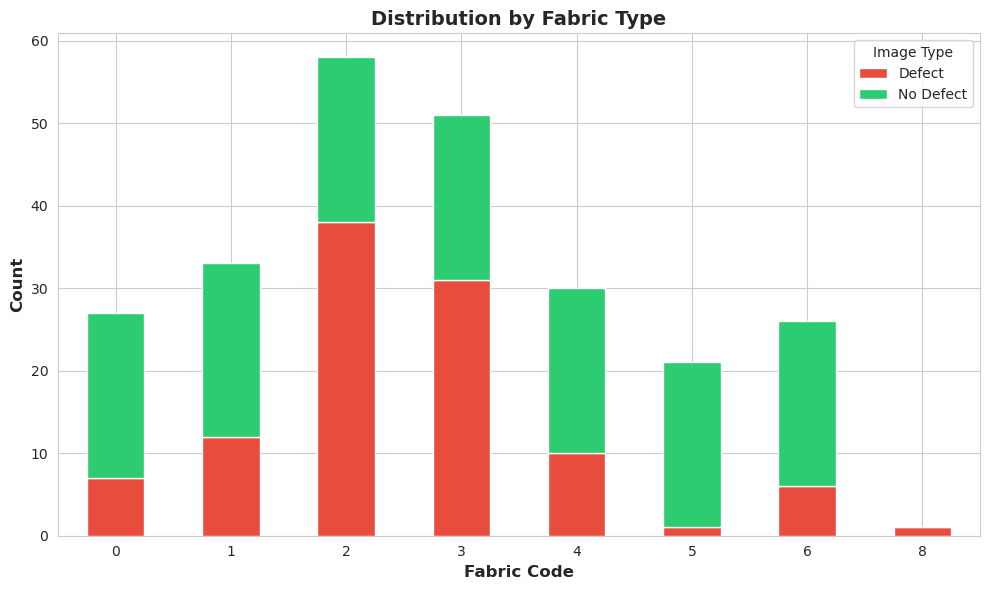

In [8]:
# Visualize fabric distribution
fig = plot_fabric_distribution(df)
plt.show()

### 5.3 Fabric vs Defect Correlation

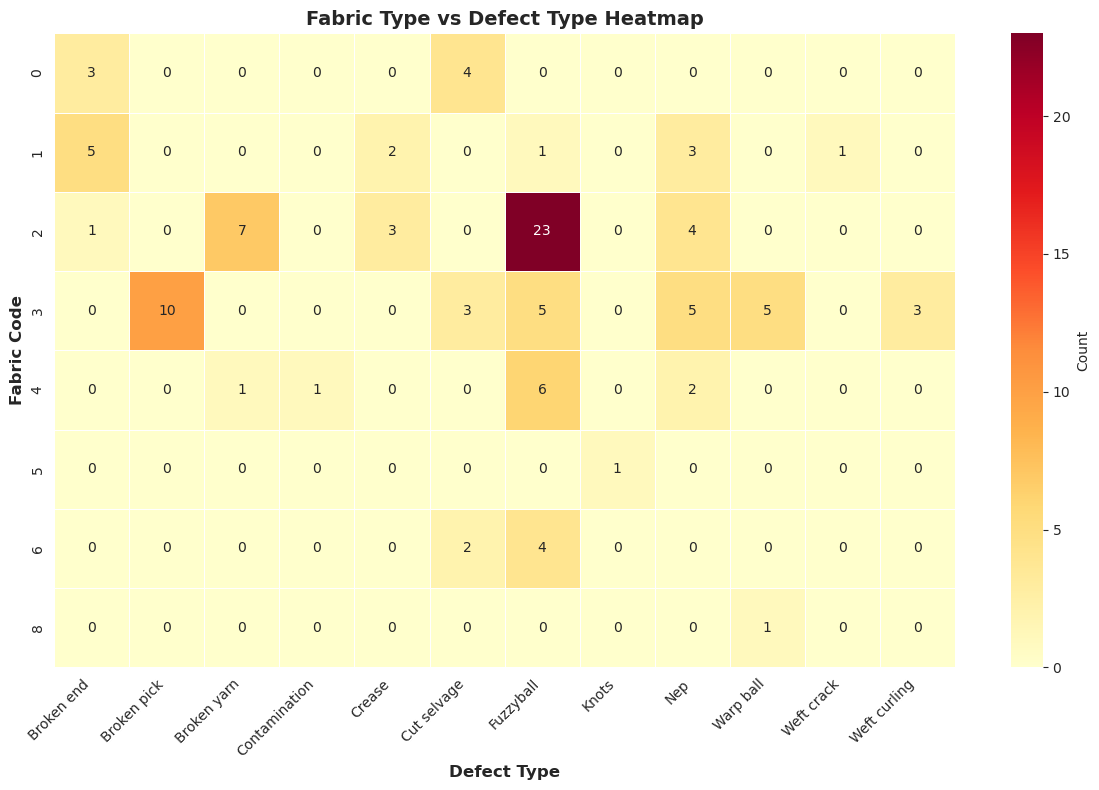

In [9]:
# Visualize as heatmap
fabric_defect_matrix = compute_fabric_defect_matrix(df)
fig = plot_fabric_defect_heatmap(fabric_defect_matrix)
plt.show()


fabric_defect_matrix = compute_fabric_defect_matrix(df)## 6. Visual Inspection: Image Triplets

Side-by-side visualization of original images, binary masks, and cropped defects.

### 6.1 Single Example

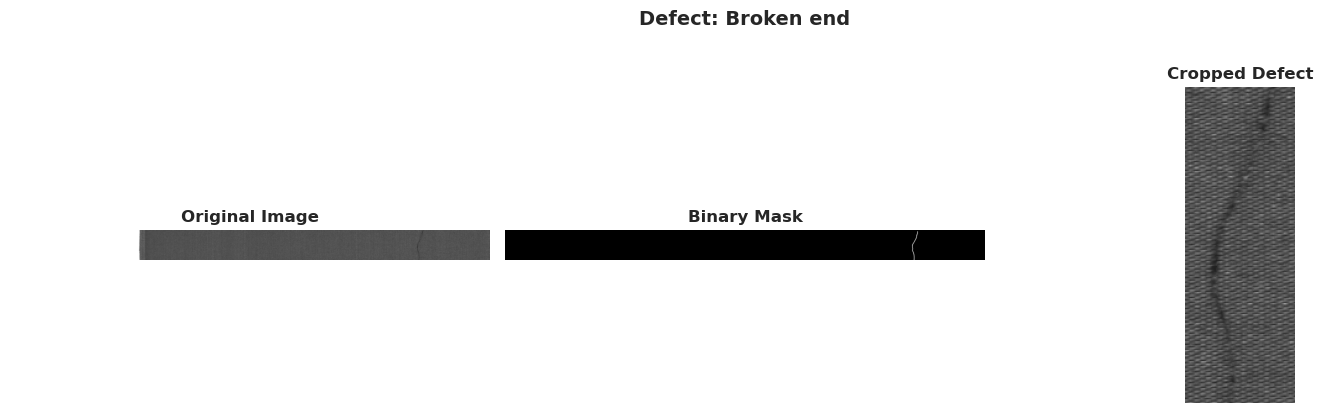


Image Details:
  Image ID: 1
  Defect: Broken end
  Fabric Code: 0
  Defect Area: 12054 pixels
  Coverage: 0.133%
  Aspect Ratio: 0.20


In [10]:
# Show one detailed example
sample = df[df['has_defect'] == True].iloc[0]
fig = plot_image_triplet(
    sample['image_path'],
    sample['mask_path'],
    defect_name=sample['defect_name']
)
plt.show()

print(f"\nImage Details:")
print(f"  Image ID: {sample['image_id']}")
print(f"  Defect: {sample['defect_name']}")
print(f"  Fabric Code: {sample['fabric_code']}")
print(f"  Defect Area: {sample['defect_area']:.0f} pixels")
print(f"  Coverage: {sample['defect_percentage']:.3f}%")
print(f"  Aspect Ratio: {sample['aspect_ratio']:.2f}")

### 6.2 Multiple Examples Grid

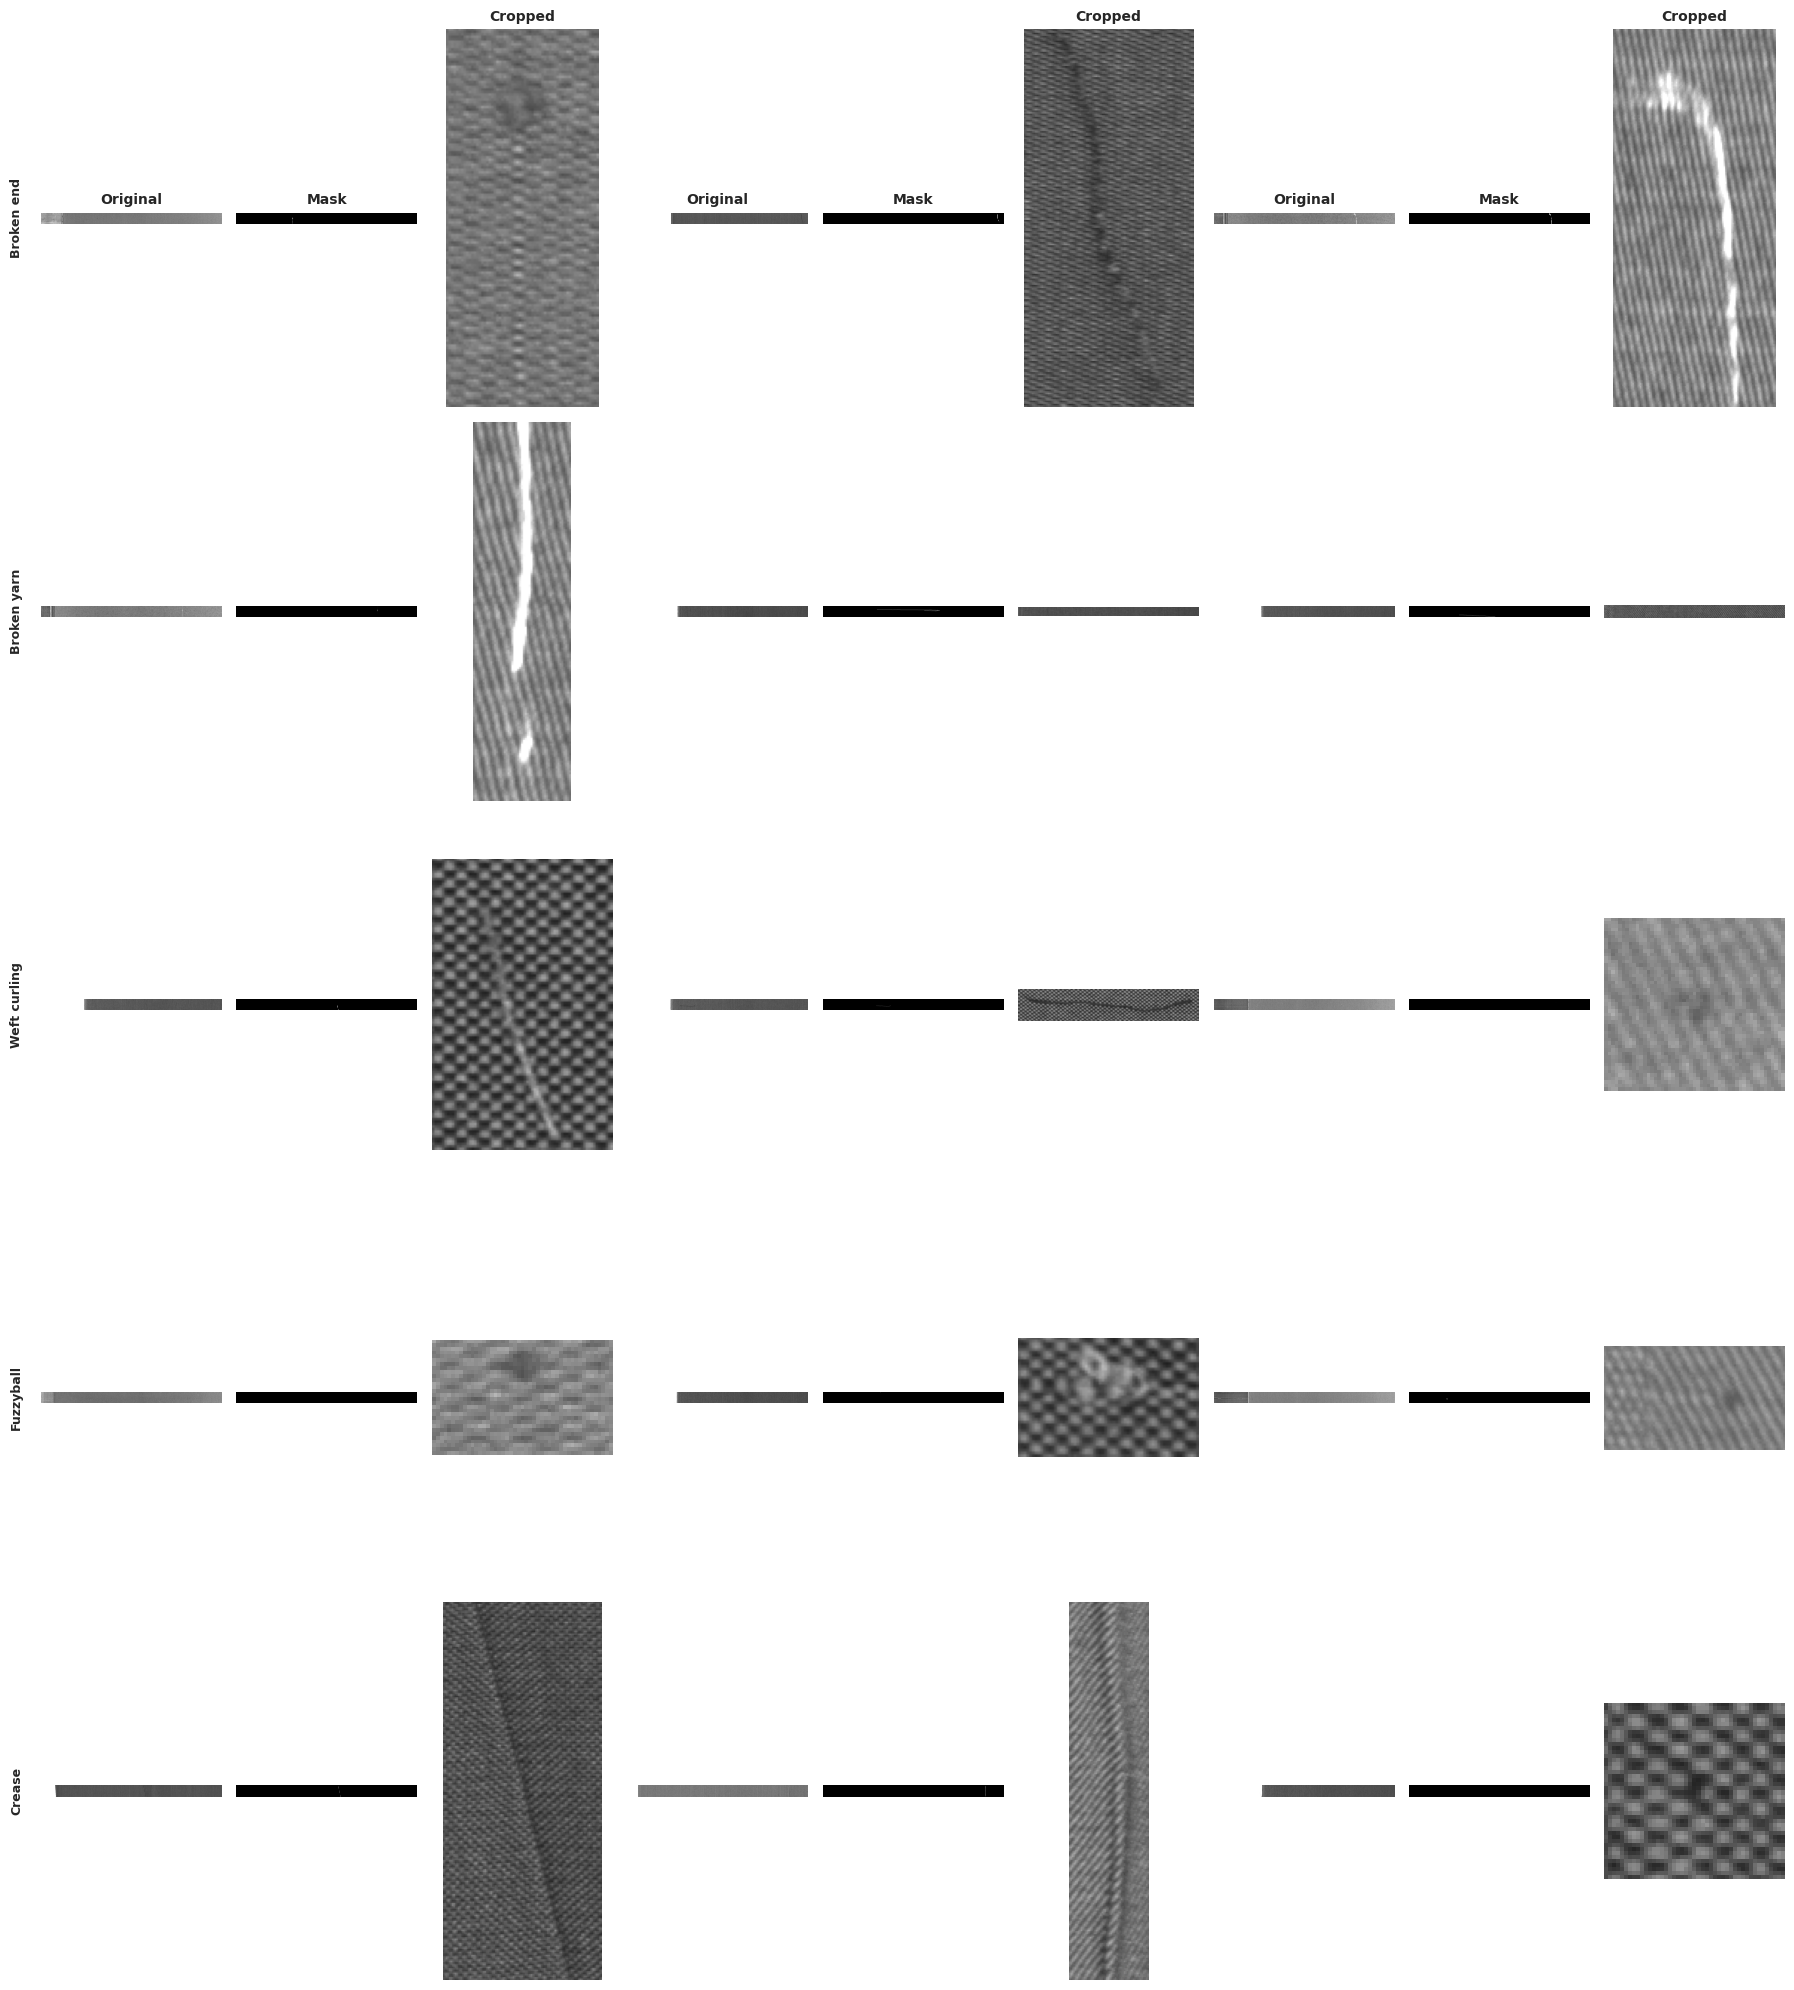

In [11]:
# Get diverse samples across different defect types
samples = get_sample_images(df, n_samples=15, defects_only=True)

# Plot grid of triplets
fig = plot_multiple_triplets(samples, n_samples=15, cols=3)
plt.show()

## 7. Defect Size Analysis

### 7.1 Overall Size Distribution

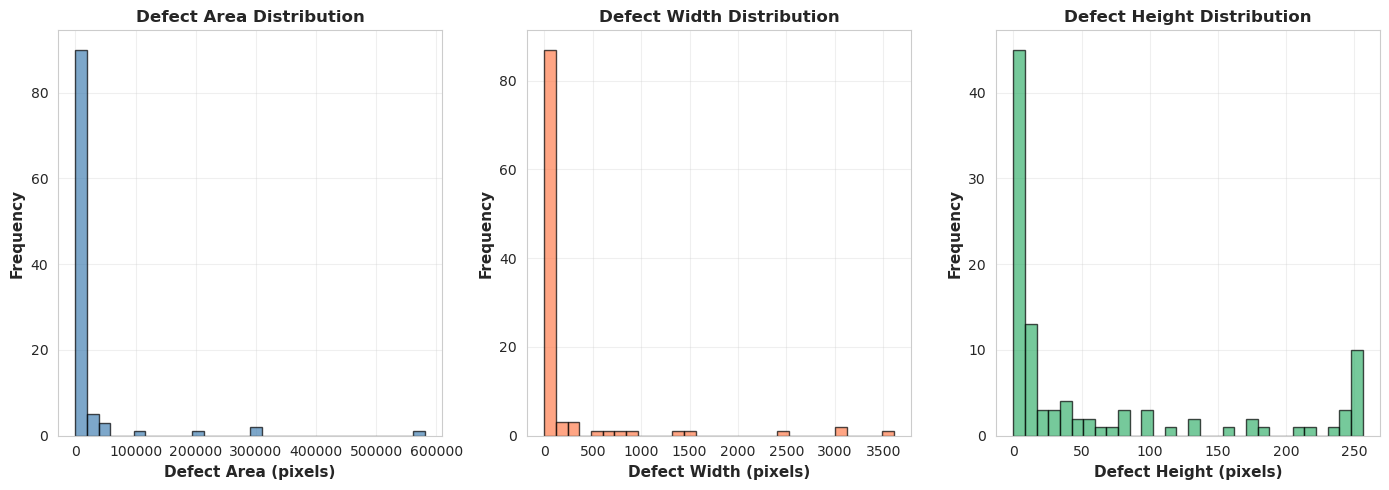

In [12]:
# Plot size distributions
fig = plot_defect_size_distribution(df)
plt.show()

### 7.2 Size by Defect Type

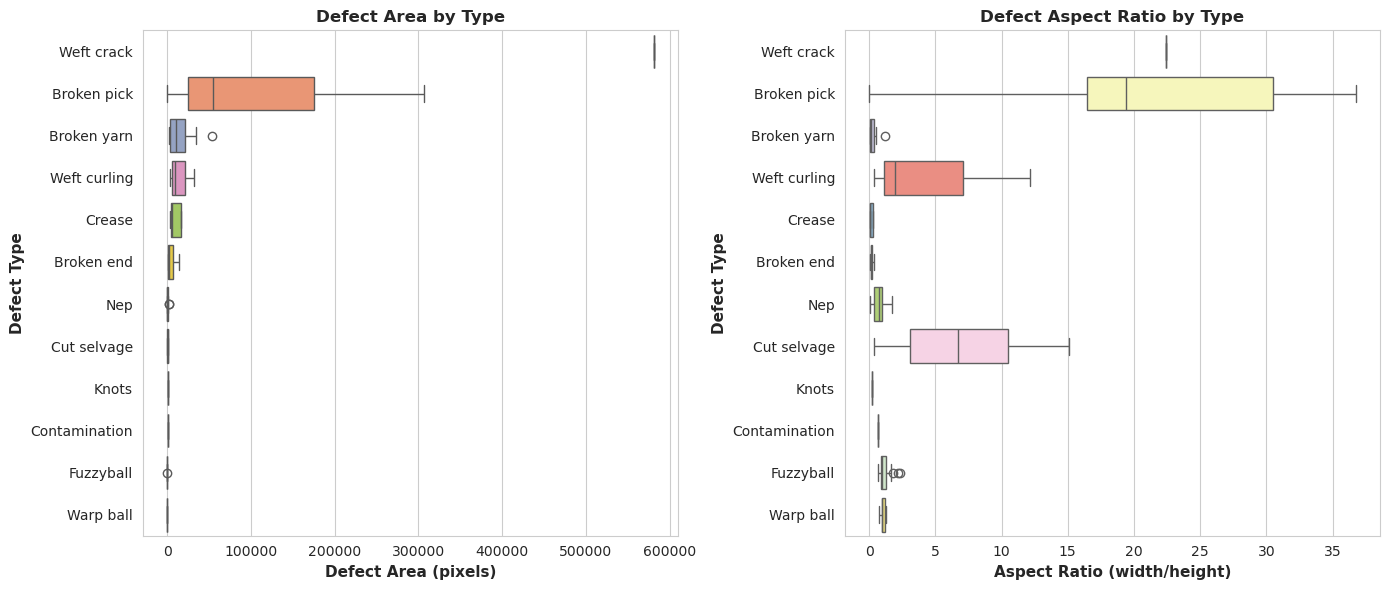

In [13]:
# Compare sizes across defect types
fig = plot_defect_size_by_type(df)
plt.show()

### 7.3 Defect Coverage Analysis

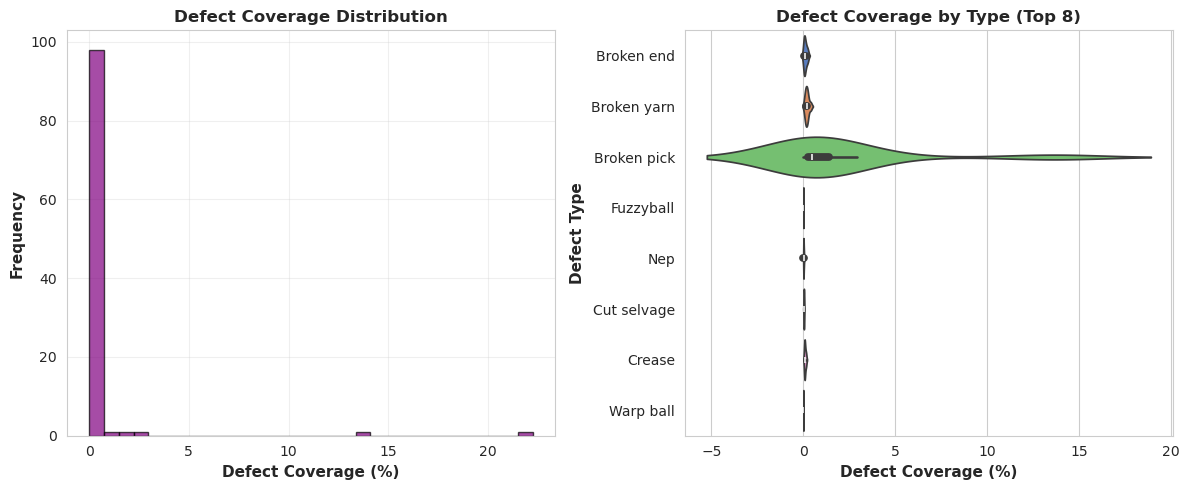

In [14]:
# Analyze defect coverage percentage
fig = plot_defect_percentage_distribution(df)
plt.show()

## 8. Spatial Analysis

In [15]:
# Compute spatial statistics
spatial_stats = compute_spatial_statistics(df)

print("\n" + "="*50)
print("SPATIAL DISTRIBUTION")
print("="*50)
print("\nHorizontal Distribution:")
for region, count in spatial_stats['horizontal_distribution'].items():
    print(f"  {region}: {count}")

print("\nVertical Distribution:")
for region, count in spatial_stats['vertical_distribution'].items():
    print(f"  {region}: {count}")

print(f"\nMean Position (normalized):")
print(f"  X: {spatial_stats['mean_x_norm']:.3f} ± {spatial_stats['std_x_norm']:.3f}")
print(f"  Y: {spatial_stats['mean_y_norm']:.3f} ± {spatial_stats['std_y_norm']:.3f}")


SPATIAL DISTRIBUTION

Horizontal Distribution:
  center: 48
  right: 35
  left: 23

Vertical Distribution:
  middle: 45
  top: 34
  bottom: 27

Mean Position (normalized):
  X: 0.544 ± 0.227
  Y: 0.441 ± 0.254


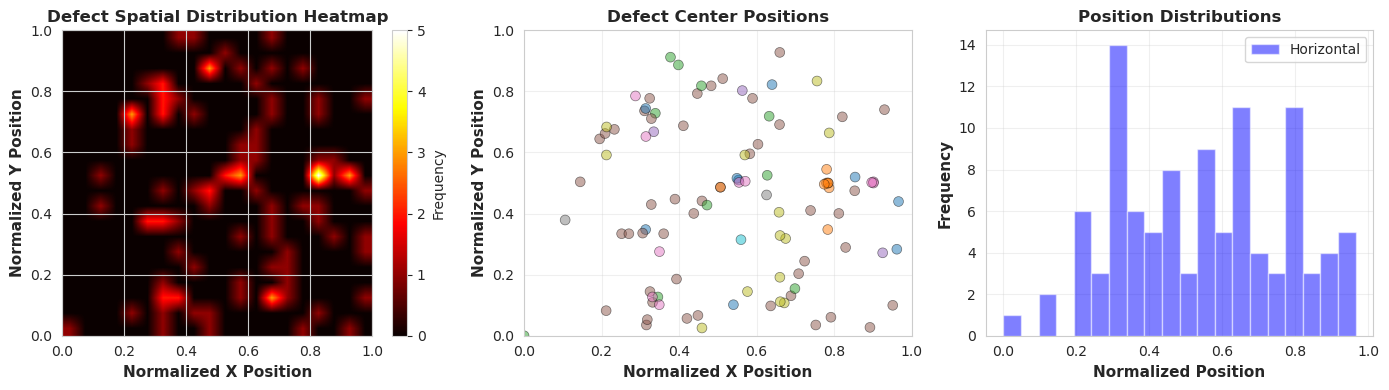

In [16]:
# Visualize spatial distribution
fig = plot_spatial_heatmap(df)
plt.show()

## 9. Defect Orientation Analysis

In [17]:
# Analyze defect orientation
orientation_stats = analyze_defect_orientation(df)
display(orientation_stats)

,orientation,image_id_count,aspect_ratio_mean,aspect_ratio_median,aspect_ratio_min,aspect_ratio_max
0,horizontal,20,15.82,15.10,2.17,36.74
1,square,54,1.07,1.00,0.55,1.95
2,unknown,4,0.00,0.00,0.00,0.00
3,vertical,28,0.19,0.18,0.03,0.40


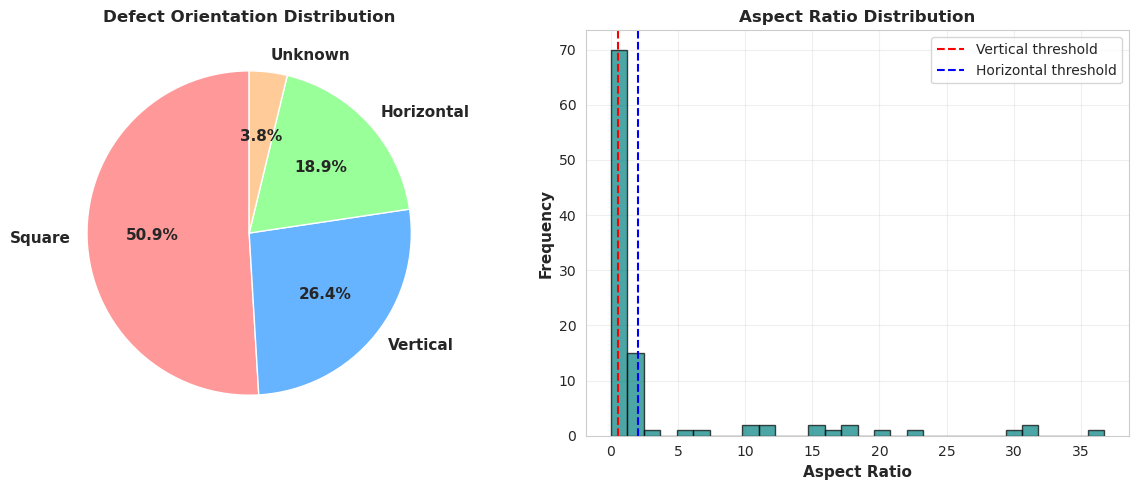

In [18]:
# Visualize orientation distribution
fig = plot_orientation_analysis(df)
plt.show()

## 10. Interactive Exploration

In [19]:
# Interactive Plotly visualization
fig = plot_interactive_defect_explorer(df)
fig.show()

ValueError: 
    Invalid element(s) received for the 'size' property of scatter.marker
        Invalid elements include: [nan]

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above

## 11. Key Insights & Observations

In [ ]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Most common defect
most_common = df[df['has_defect']]['defect_name'].value_counts().iloc[0:3]
print("\n1. Most Common Defects:")
for defect, count in most_common.items():
    print(f"   - {defect}: {count} occurrences")

# Largest defects
print("\n2. Largest Average Defect Area:")
largest = defect_stats.nlargest(3, 'defect_area_mean')[['defect_name', 'defect_area_mean']]
for _, row in largest.iterrows():
    print(f"   - {row['defect_name']}: {row['defect_area_mean']:.0f} pixels")

# Fabric with most defects
print("\n3. Fabric Types with Highest Defect Rate:")
high_defect = fabric_stats.nlargest(3, 'defect_rate')[['fabric_code', 'defect_rate']]
for _, row in high_defect.iterrows():
    print(f"   - Fabric {row['fabric_code']}: {row['defect_rate']:.1f}% defect rate")

# Size variability
defect_df = df[df['has_defect'] == True]
size_cv = defect_df['defect_area'].std() / defect_df['defect_area'].mean()
print(f"\n4. Defect Size Variability:")
print(f"   - Coefficient of Variation: {size_cv:.2f}")
print(f"   - This indicates {'high' if size_cv > 1 else 'moderate'} variability in defect sizes")

print("\n" + "="*70)

## 12. Advanced Analysis Suggestions

Based on this EDA, here are additional analyses worth exploring:

### 12.1 Machine Learning Approaches
- **Defect Classification**: Train CNN models to classify defect types
- **Semantic Segmentation**: U-Net or DeepLab for pixel-wise defect detection
- **Anomaly Detection**: One-class SVM or autoencoders for detecting unknown defects
- **Transfer Learning**: Fine-tune pre-trained models (ResNet, EfficientNet) on this dataset

### 12.2 Feature Engineering
- **Texture Analysis**: GLCM (Gray-Level Co-occurrence Matrix) features
- **Local Binary Patterns (LBP)**: For texture characterization
- **Frequency Domain**: FFT analysis to detect periodic patterns
- **Edge Detection**: Canny, Sobel for defect boundary analysis
- **Color Histograms**: Distribution of pixel intensities in defect regions

### 12.3 Statistical Analysis
- **Correlation Analysis**: Between defect characteristics and fabric types
- **Clustering**: K-means or DBSCAN on defect features to find natural groupings
- **Principal Component Analysis**: Dimensionality reduction on defect features
- **Hypothesis Testing**: Chi-square tests for defect-fabric independence

### 12.4 Advanced Visualizations
- **t-SNE/UMAP**: Visualize defect embeddings in 2D space
- **Grad-CAM**: Visualize what CNN models focus on when classifying
- **Attention Maps**: For transformer-based models
- **3D Surface Plots**: Defect characteristics across multiple dimensions

### 12.5 Quality Control Metrics
- **Defect Severity Scoring**: Weighted score based on area, location, type
- **False Positive Analysis**: Expected rate from production scenarios
- **Cost-Benefit Analysis**: Economic impact of different defect types
- **Confidence Intervals**: For defect detection models

### 12.6 Time Series Analysis (if applicable)
- **Temporal Patterns**: Defect occurrence over time from image IDs
- **Production Batch Analysis**: Correlation with manufacturing batches
- **Seasonal Trends**: If timestamp data available

### 12.7 Multi-Scale Analysis
- **Pyramid Analysis**: Defect detection at multiple resolutions
- **Wavelet Transforms**: Multi-scale frequency analysis
- **Super-Resolution**: Enhance defect details for better classification

### 12.8 Data Augmentation Strategies
- **Synthetic Defects**: Generate artificial defects for training
- **GAN-based Augmentation**: Create realistic defect variations
- **Mixup/Cutmix**: Advanced augmentation techniques

### 12.9 Comparative Analysis
- **Human vs Model Performance**: Agreement between annotators and models
- **Inter-annotator Agreement**: If multiple labels exist
- **Cross-Dataset Evaluation**: Generalization to other fabric datasets

### 12.10 Explainability & Interpretability
- **SHAP Values**: Explain model predictions
- **LIME**: Local interpretable model explanations
- **Feature Importance**: Which features matter most for classification

## 13. Export Dataset Summary

In [ ]:
# Save enhanced dataframe with all statistics
output_path = '../data/aitex_dataset_with_statistics.csv'
df.to_csv(output_path, index=False)
print(f"✓ Dataset with statistics saved to: {output_path}")

# Save defect statistics
defect_stats.to_csv('../data/defect_statistics.csv', index=False)
print(f"✓ Defect statistics saved")

# Save fabric statistics
fabric_stats.to_csv('../data/fabric_statistics.csv', index=False)
print(f"✓ Fabric statistics saved")

---

## Conclusion

This EDA provides a comprehensive overview of the AITEX Fabric Defect Dataset:

- ✅ Dataset structure and composition analyzed
- ✅ Defect types and distributions quantified  
- ✅ Visual inspection with side-by-side comparisons
- ✅ Spatial patterns and size characteristics explored
- ✅ Fabric-defect correlations identified
- ✅ Orientation and coverage metrics computed

The modular structure (data_loader.py, statistics.py, visualization.py) makes it easy to extend this analysis with additional metrics and visualizations as needed.